# 03 - Análise dos produtos

Objetivo: Analisar tendências relacionadas aos produtos dispostos no dataset.

Perguntas que esse notebook responde:  

- Quais categorias de produtos vendem mais?   
- Qual o ticket médio por categoria?  
- Qual é a relação, se ela existe, entre o peso do produto e o frete?  
- Quais categorias têm as melhores e piores avaliações?  

Dataset utilizados: order_items, products, category_translation, reviews

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.titlesize'] = 13

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings 
warnings.filterwarnings('ignore')

In [3]:
DATA_PATH = '../data/raw/'

items = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
reviews = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
category = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

## Preparação dos Dados


In [4]:
# order_items + products -> Traz a categoria de cada item vendido

df = pd.merge(
    items,
    products[['product_id', 'product_category_name', 'product_weight_g']],
    on='product_id',
    how='left'
)

# traduz o nome da categoria

df = pd.merge(
    df,
    category,
    on='product_category_name',
    how='left'
)

# Traz a avaliação

df = pd.merge(
    df,
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)


## 1. Categorias que mais vendem

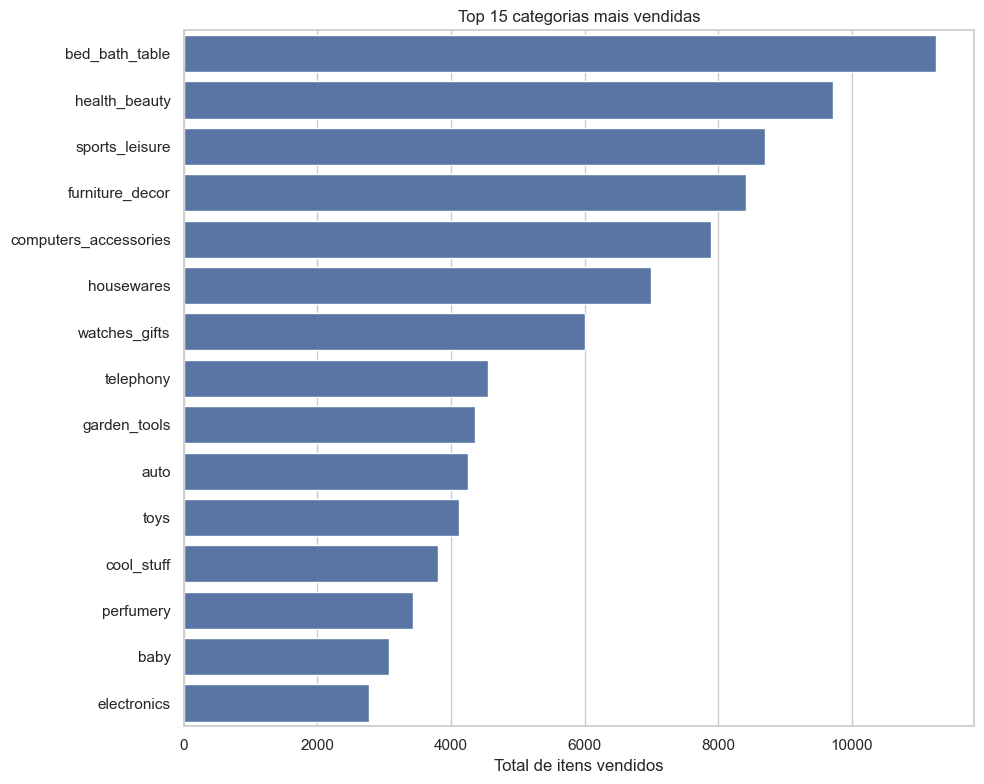

In [5]:
top_categorias = (
    df.groupby('product_category_name_english')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_categorias.columns = ['categoria', 'total_vendas']

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_categorias, x='total_vendas', y='categoria', ax=ax)

ax.set_title('Top 15 categorias mais vendidas')
ax.set_xlabel('Total de itens vendidos')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/03_top_categorias.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusão

Cama, mesa e banho lidera em volume de vendas, seguida de saúde e beleza — categorias com alta recorrência de compra e ticket acessível, o que explica o volume alto. Em um cenário real, essas categorias mereceriam atenção prioritária em estoque, precificação e logística.

## 2. Ticket médio por categoria


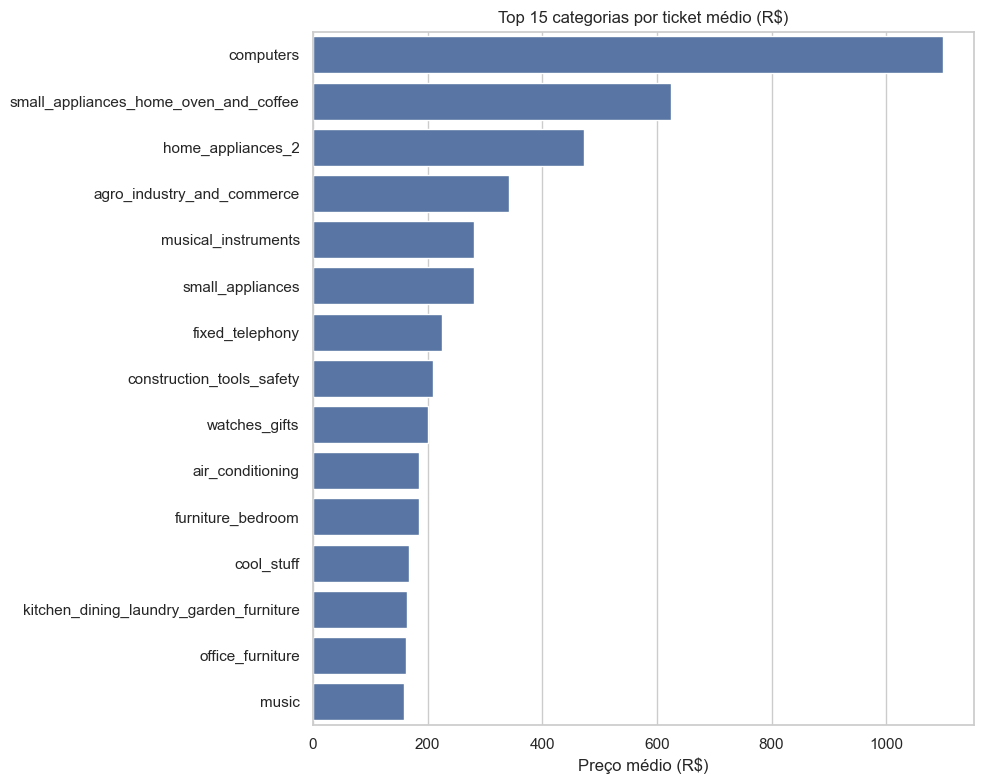

In [10]:
ticket_medio = (
    df.groupby('product_category_name_english')['price']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
ticket_medio.columns = ['categoria', 'ticket_medio']

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=ticket_medio, x='ticket_medio', y='categoria', ax=ax)

ax.set_title('Top 15 categorias por ticket médio (R$)')
ax.set_xlabel('Preço médio (R$)')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/03_ticket_medio.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusão

As categorias com maior ticket médio — computadores (~R$1.100), pequenos eletrodomésticos (~R$620) e eletrodomésticos (~R$470) são completamente diferentes das que lideram em volume de vendas.

Esse padrão é esperado: produtos de alto valor têm menor frequência de compra mas maior impacto na receita por pedido. Em um cenário real, uma estratégia saudável equilibra categorias de alto volume (recorrência) com categorias de alto ticket (margem).

## 3. Relação entre peso do produto e valor do frete

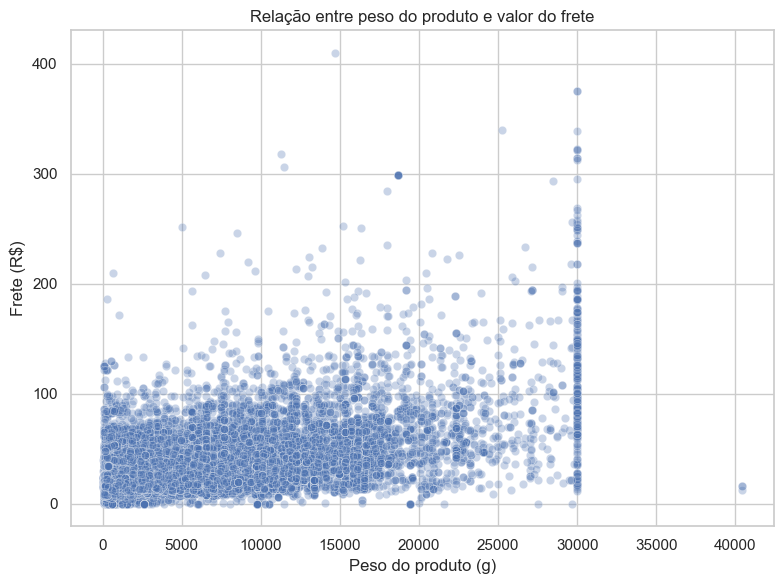

In [11]:
# removendo valores nulos
df_peso_frete = df[['product_weight_g', 'freight_value']].dropna()

# correlação
correlacao = df_peso_frete.corr().iloc[0,1]

# scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_peso_frete,
    x='product_weight_g',
    y='freight_value',
    alpha=0.3
)

plt.title('Relação entre peso do produto e valor do frete')
plt.xlabel('Peso do produto (g)')
plt.ylabel('Frete (R$)')

plt.tight_layout()
plt.savefig('../reports/figures/03_peso_vs_frete.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusão

Apesar de existir uma tendência de aumento do frete com o peso, a relação observada é fraca, indicando que o peso do produto não é o principal fator determinante do custo logístico. 

A dispersão dos dados sugere influência significativa de outras variáveis, como dimensões do produto e distância de entrega. Além disso, foi identificado um acúmulo anômalo de produtos com peso próximo a 30kg, indicando possível limitação ou padronização nos dados.

## 4. Quais Categorias tem as melhores e piores avaliações?

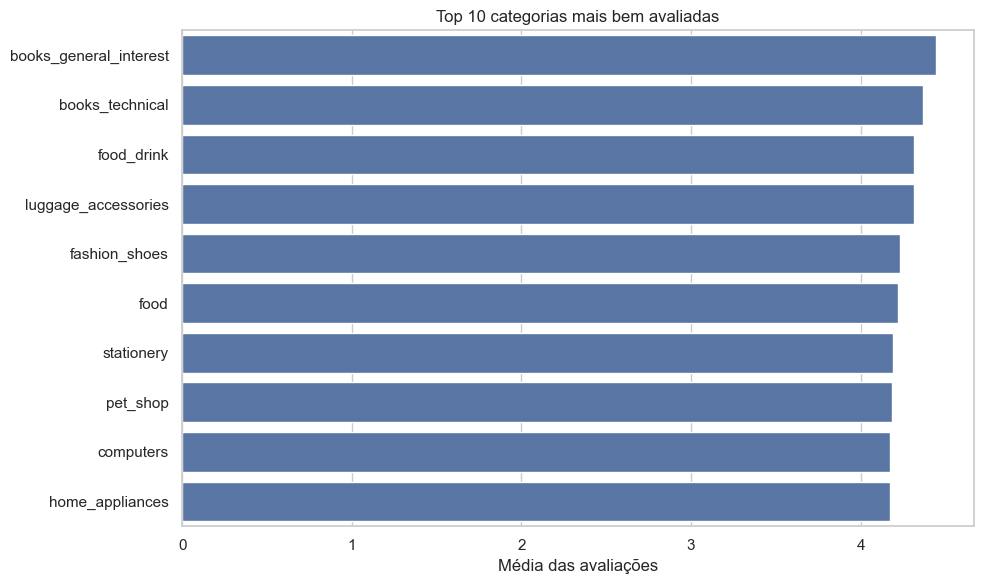

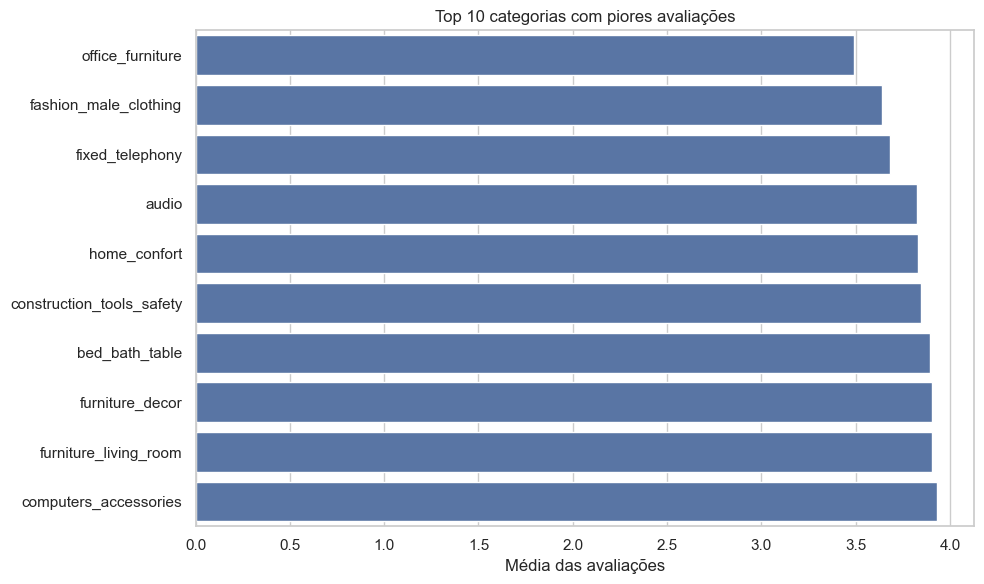

In [12]:
avaliacoes_categoria = (
    df.groupby('product_category_name_english')
    .agg(
        media_avaliacao=('review_score', 'mean'),
        total_avaliacoes=('review_score', 'count')
    )
    .reset_index()
)

avaliacoes_filtradas = avaliacoes_categoria[
    avaliacoes_categoria['total_avaliacoes'] >= 100
]

# melhores
melhores = (
    avaliacoes_filtradas
    .sort_values(by='media_avaliacao', ascending=False)
    .head(10)
)

# piores
piores = (
    avaliacoes_filtradas
    .sort_values(by='media_avaliacao', ascending=True)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(data=melhores, x='media_avaliacao', y='product_category_name_english')

plt.title('Top 10 categorias mais bem avaliadas')
plt.xlabel('Média das avaliações')
plt.ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/03_melhores_avaliacoes.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=piores, x='media_avaliacao', y='product_category_name_english')

plt.title('Top 10 categorias com piores avaliações')
plt.xlabel('Média das avaliações')
plt.ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/03_piores_avaliacoes.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusão

A análise das avaliações por categoria revela um padrão consistente: produtos com menor complexidade logística, como livros e alimentos, apresentam as maiores médias de avaliação. Em contrapartida, categorias como móveis e itens de casa concentram as piores avaliações, possivelmente devido a desafios na entrega, montagem e maior subjetividade na percepção de qualidade.

Apesar dessas diferenças, a variação geral das avaliações não é extrema, indicando que o nível de satisfação do cliente é relativamente alto em todas as categorias. No entanto, categorias com alto volume de vendas e avaliações mais baixas representam oportunidades claras de melhoria operacional e ganho competitivo.
